# Первая модель прогноза ухода клиента

В этом ноутбуке мы строим первую рабочую модель прогноза ухода клиента на основе истории заказов и поведенческих событий.

## Что хотим получить

Нам нужна не просто любая модель, а понятный базовый вариант, который:

- можно объяснить на защите;
- даёт оценку риска ухода;
- показывает, какие признаки сильнее всего связаны с риском;
- станет основой для более продвинутой версии.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid", context="talk")

BASE_DIR = Path("..")
DATA_PATH = BASE_DIR / "data.csv"
EVENTS_PATH = BASE_DIR / "events.csv"


In [2]:
def parse_dt(series: pd.Series) -> pd.Series:
    return pd.to_datetime(series, utc=True, errors="coerce", format="mixed")


def top_share_precision(y_true: pd.Series, y_score: np.ndarray, top_share: float = 0.2) -> float:
    n_top = max(1, int(len(y_score) * top_share))
    idx = np.argsort(-y_score)[:n_top]
    return y_true.iloc[idx].mean()


## 1. Собираем обучающую таблицу

Повторяем выбранную бизнес-логику:

- берём клиентов с повторной покупкой или признаком лояльности;
- смотрим их историю до даты-среза;
- если в следующие `180` дней заказа не было, считаем клиента ушедшим.

In [3]:
data_cols = [
    "order_id", "order_item_id", "user_id", "status", "gender", "created_at", "returned_at",
    "shipped_at", "delivered_at", "sale_price", "age", "state", "city", "traffic_source",
    "category", "department", "brand", "product_id", "warehouse_name", "is_loyal"
]
event_cols = [
    "id", "user_id", "session_id", "sequence_number", "created_at", "traffic_source",
    "browser", "uri", "event_type"
]

data = pd.read_csv(DATA_PATH, usecols=data_cols)
events = pd.read_csv(EVENTS_PATH, usecols=event_cols)

for col in ["created_at", "returned_at", "shipped_at", "delivered_at"]:
    data[col] = parse_dt(data[col])
events["created_at"] = parse_dt(events["created_at"])

data.shape, events.shape


((545778, 20), (4865324, 9))

In [4]:
data = data.drop_duplicates(subset=["order_item_id"]).copy()
events = events.drop_duplicates(subset=["id"]).copy()

data["city"] = data["city"].fillna("unknown")
data["brand"] = data["brand"].fillna("unknown")
data["sale_price"] = data["sale_price"].clip(lower=0)

data["ship_delay_days"] = (data["shipped_at"] - data["created_at"]).dt.total_seconds() / 86400
data["delivery_days"] = (data["delivered_at"] - data["shipped_at"]).dt.total_seconds() / 86400
data["return_days"] = (data["returned_at"] - data["delivered_at"]).dt.total_seconds() / 86400
data["is_returned"] = data["returned_at"].notna().astype(int)
data["is_cancelled"] = data["status"].eq("Cancelled").astype(int)
data["is_delivered"] = data["delivered_at"].notna().astype(int)

orders = (
    data.groupby("order_id", as_index=False)
    .agg(
        user_id=("user_id", "first"),
        created_at=("created_at", "min"),
        order_value=("sale_price", "sum"),
        items_count=("order_item_id", "nunique"),
        status=("status", "first"),
        is_loyal=("is_loyal", "max"),
    )
    .dropna(subset=["user_id", "created_at"])
)
orders["created_at_naive"] = orders["created_at"].dt.tz_localize(None)
orders.head()


,order_id,user_id,created_at,order_value,items_count,status,is_loyal,created_at_naive
0,1,1,2024-10-14 10:31:40+00:00,55.490002,1,Complete,False,2024-10-14 10:31:40
1,2,2,2025-04-11 13:43:06+00:00,124.000000,2,Complete,True,2025-04-11 13:43:06
2,3,2,2020-06-24 23:00:38+00:00,47.500000,2,Cancelled,True,2020-06-24 23:00:38
3,4,3,2022-09-05 21:23:16+00:00,51.990000,2,Returned,False,2022-09-05 21:23:16
4,5,4,2026-02-28 07:34:44+00:00,22.500000,1,Shipped,False,2026-02-28 07:34:44


In [5]:
CUTOFF_DATE = pd.Timestamp("2025-06-01")
LOOKBACK_DAYS = 365
CHURN_HORIZON_DAYS = 180

LOOKBACK_START = CUTOFF_DATE - pd.Timedelta(days=LOOKBACK_DAYS)
HORIZON_END = CUTOFF_DATE + pd.Timedelta(days=CHURN_HORIZON_DAYS)


In [6]:
history_orders = orders.loc[orders["created_at_naive"] < CUTOFF_DATE].copy()
future_orders = orders.loc[
    (orders["created_at_naive"] >= CUTOFF_DATE) &
    (orders["created_at_naive"] < HORIZON_END)
].copy()

user_history = (
    history_orders.groupby("user_id", as_index=False)
    .agg(
        total_orders_before_cutoff=("order_id", "nunique"),
        loyal_flag=("is_loyal", "max"),
        first_order_at=("created_at_naive", "min"),
        last_order_at=("created_at_naive", "max"),
    )
)

target = user_history.loc[
    (user_history["total_orders_before_cutoff"] >= 2) | (user_history["loyal_flag"] == True)
].copy()

future_buyers = set(future_orders["user_id"].unique())
target["churn_target"] = (~target["user_id"].isin(future_buyers)).astype(int)
target[["user_id", "total_orders_before_cutoff", "loyal_flag", "churn_target"]].head()


,user_id,total_orders_before_cutoff,loyal_flag,churn_target
1,2,2,True,1
5,8,1,True,0
6,10,1,True,1
7,13,2,False,1
8,14,1,True,0


In [7]:
data_window = data.loc[
    (data["created_at"].dt.tz_localize(None) >= LOOKBACK_START) &
    (data["created_at"].dt.tz_localize(None) < CUTOFF_DATE)
].copy()

orders_window = history_orders.loc[
    (history_orders["created_at_naive"] >= LOOKBACK_START) &
    (history_orders["created_at_naive"] < CUTOFF_DATE)
].copy()

events = events.dropna(subset=["user_id", "created_at"]).copy()
events["user_id"] = events["user_id"].astype(int)
events["created_at_naive"] = events["created_at"].dt.tz_localize(None)
events["is_product_event"] = events["event_type"].eq("product").astype(int)
events["is_cart_event"] = events["event_type"].eq("cart").astype(int)
events["is_purchase_event"] = events["event_type"].eq("purchase").astype(int)
events["is_department_event"] = events["event_type"].eq("department").astype(int)

events_window = events.loc[
    (events["created_at_naive"] >= LOOKBACK_START) &
    (events["created_at_naive"] < CUTOFF_DATE)
].copy()


In [8]:
customer_orders = (
    orders_window.groupby("user_id", as_index=False)
    .agg(
        orders_last_365d=("order_id", "nunique"),
        revenue_last_365d=("order_value", "sum"),
        avg_order_value_last_365d=("order_value", "mean"),
        median_order_value_last_365d=("order_value", "median"),
        avg_items_per_order_last_365d=("items_count", "mean"),
        first_order_in_window=("created_at_naive", "min"),
        last_order_in_window=("created_at_naive", "max"),
    )
)
customer_orders["days_since_last_order"] = (CUTOFF_DATE - customer_orders["last_order_in_window"]).dt.days
customer_orders["active_days_in_window"] = (customer_orders["last_order_in_window"] - customer_orders["first_order_in_window"]).dt.days

customer_logistics = (
    data_window.groupby("user_id", as_index=False)
    .agg(
        returned_items_count=("is_returned", "sum"),
        cancelled_items_count=("is_cancelled", "sum"),
        delivered_items_count=("is_delivered", "sum"),
        return_rate_items=("is_returned", "mean"),
        cancel_rate_items=("is_cancelled", "mean"),
        avg_ship_delay_days=("ship_delay_days", "mean"),
        median_delivery_days=("delivery_days", "median"),
        avg_return_days=("return_days", "mean"),
        avg_sale_price=("sale_price", "mean"),
        median_sale_price=("sale_price", "median"),
        age=("age", "median"),
        gender=("gender", "first"),
        state=("state", "first"),
        city=("city", "first"),
        main_traffic_source=("traffic_source", lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0]),
        main_department=("department", lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0]),
        main_category=("category", lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0]),
        main_brand=("brand", lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0]),
        main_warehouse=("warehouse_name", lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0]),
    )
)

customer_events = (
    events_window.groupby("user_id", as_index=False)
    .agg(
        sessions_last_365d=("session_id", "nunique"),
        events_last_365d=("id", "count"),
        product_views_last_365d=("is_product_event", "sum"),
        cart_events_last_365d=("is_cart_event", "sum"),
        purchase_events_last_365d=("is_purchase_event", "sum"),
        department_events_last_365d=("is_department_event", "sum"),
        last_event_at=("created_at_naive", "max"),
        main_browser=("browser", lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0]),
        event_traffic_source=("traffic_source", lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0]),
    )
)
customer_events["days_since_last_event"] = (CUTOFF_DATE - customer_events["last_event_at"]).dt.days
customer_events["events_per_session_last_365d"] = customer_events["events_last_365d"] / customer_events["sessions_last_365d"]

model_data = (
    target
    .merge(customer_orders, on="user_id", how="left")
    .merge(customer_logistics, on="user_id", how="left")
    .merge(customer_events, on="user_id", how="left")
)

model_data.shape


(20886, 45)

In [9]:
summary = pd.Series(
    {
        "clients_in_model": len(model_data),
        "churn_share": round(model_data["churn_target"].mean(), 4),
        "share_loyal": round(model_data["loyal_flag"].mean(), 4),
        "avg_orders_before_cutoff": round(model_data["total_orders_before_cutoff"].mean(), 2),
    }
).to_frame("value")
summary


,value
clients_in_model,20886.0000
churn_share,0.8061
share_loyal,0.5781
avg_orders_before_cutoff,2.1400


## 2. Делим данные на обучение и проверку

In [10]:
drop_cols = [
    "user_id", "first_order_at", "last_order_at", "first_order_in_window", "last_order_in_window",
    "last_event_at", "churn_target"
]

feature_cols = [col for col in model_data.columns if col not in drop_cols]
X = model_data[feature_cols].copy()
y = model_data["churn_target"].copy()

categorical_cols = X.select_dtypes(include=["object", "bool"]).columns.tolist()
numeric_cols = [col for col in X.columns if col not in categorical_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

X_train.shape, X_test.shape


((15664, 38), (5222, 38))

## 3. Обучаем две модели

Сначала строим простую линейную модель как базовый ориентир, затем более гибкую модель на деревьях.

In [11]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)

logreg_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced")),
    ]
)

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=20,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        )),
    ]
)


In [12]:
logreg_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['total_orders_before_cutoff',
                                                   'orders_last_365d',
                                                   'revenue_last_365d',
                                                   'avg_order_value_last_365d',
                                                   'median_order_value_last_365d',
                                                   'avg_items_per_order_last_365d',
                                                   'days_since_last_order',
                                                   'act...
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['loyal_flag', 'gender',
                                                   'state', 'city',
                                                   'main_traffic_source',
                                                   'main_department',
                                                   'main_category',
                                                   'main_brand',
                                                   'main_warehouse',
                                                   'main_browser',
                                                   'event_traffic_source'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=8,
                                        min_samples_leaf=20, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

In [13]:
def evaluate_model(model, X_test, y_test, model_name: str):
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {
        "model": model_name,
        "roc_auc": roc_auc_score(y_test, proba),
        "pr_auc": average_precision_score(y_test, proba),
        "balanced_accuracy": balanced_accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "top_20pct_precision": top_share_precision(y_test.reset_index(drop=True), proba, top_share=0.2),
    }, proba, pred


logreg_metrics, logreg_proba, logreg_pred = evaluate_model(logreg_model, X_test, y_test, "Логистическая регрессия")
rf_metrics, rf_proba, rf_pred = evaluate_model(rf_model, X_test, y_test, "Случайный лес")

metrics_df = pd.DataFrame([logreg_metrics, rf_metrics]).sort_values("roc_auc", ascending=False)
metrics_df


,model,roc_auc,pr_auc,balanced_accuracy,precision,recall,top_20pct_precision
0,Логистическая регрессия,0.777922,0.930780,0.701508,0.906269,0.707363,0.968391
1,Случайный лес,0.775382,0.927434,0.678424,0.890399,0.731354,0.969349


In [14]:
best_name = metrics_df.iloc[0]["model"]
best_model = rf_model if best_name == "Случайный лес" else logreg_model
best_pred = rf_pred if best_name == "Случайный лес" else logreg_pred
best_proba = rf_proba if best_name == "Случайный лес" else logreg_proba

print(best_name)
print(classification_report(y_test, best_pred, digits=3))
pd.DataFrame(confusion_matrix(y_test, best_pred), index=["Факт: остался", "Факт: ушёл"], columns=["Прогноз: остался", "Прогноз: ушёл"])


Логистическая регрессия
              precision    recall  f1-score   support

           0      0.364     0.696     0.478      1012
           1      0.906     0.707     0.795      4210

    accuracy                          0.705      5222
   macro avg      0.635     0.702     0.636      5222
weighted avg      0.801     0.705     0.733      5222



,Прогноз: остался,Прогноз: ушёл
Факт: остался,704,308
Факт: ушёл,1232,2978


## 4. Какие признаки важнее всего

In [15]:
perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring="roc_auc",
)

importance_df = pd.DataFrame(
    {
        "feature": X_test.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }
).sort_values("importance_mean", ascending=False)

importance_df.head(15)


,feature,importance_mean,importance_std
1,loyal_flag,0.234759,0.007524
0,total_orders_before_cutoff,0.057105,0.000830
29,events_last_365d,0.030721,0.002336
7,days_since_last_order,0.019477,0.001601
28,sessions_last_365d,0.017702,0.001614
37,events_per_session_last_365d,0.015995,0.003177
31,cart_events_last_365d,0.014241,0.001783
33,department_events_last_365d,0.014241,0.001783
30,product_views_last_365d,0.014241,0.001783
36,days_since_last_event,0.011890,0.001950


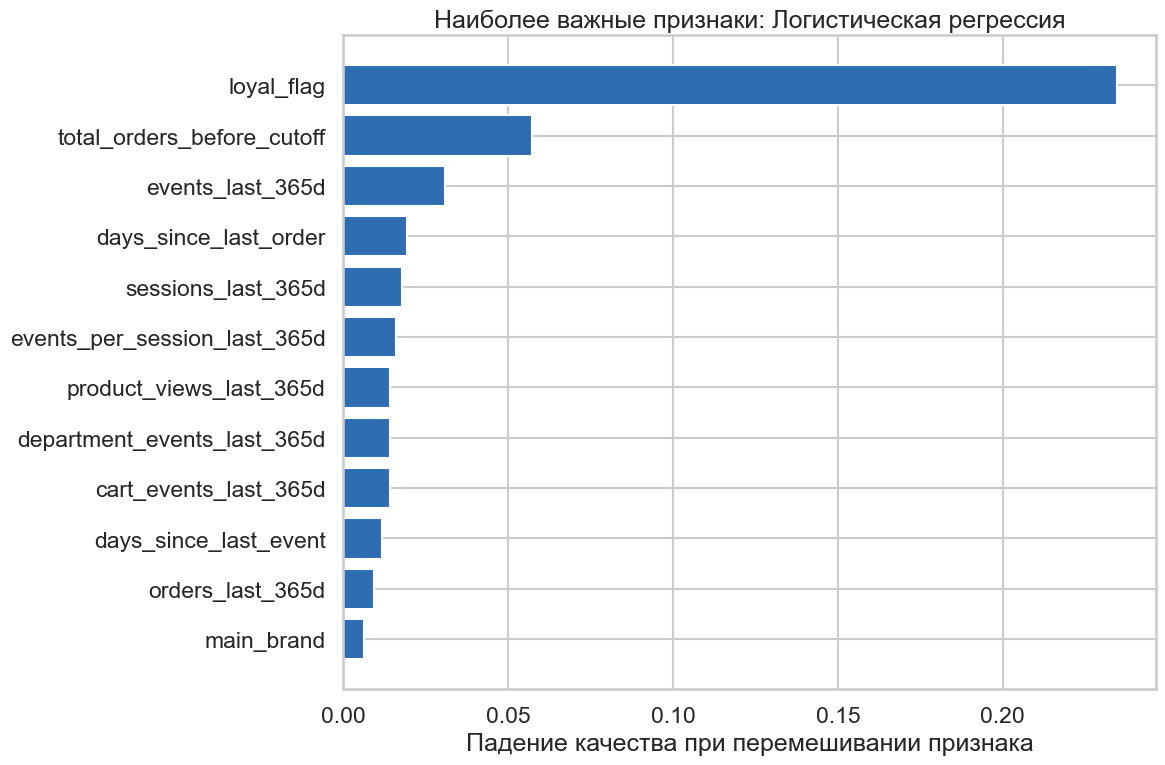

In [16]:
top_importance = importance_df.head(12).sort_values("importance_mean")

plt.figure(figsize=(12, 8))
plt.barh(top_importance["feature"], top_importance["importance_mean"], color="#2f6db3")
plt.title(f"Наиболее важные признаки: {best_name}")
plt.xlabel("Падение качества при перемешивании признака")
plt.tight_layout()
plt.show()


## 5. Как читать результат

Если в топе оказываются признаки вроде `days_since_last_order`, `orders_last_365d`, `sessions_last_365d`, `return_rate_items`, `median_delivery_days`, это хороший знак. Значит, модель опирается на понятную бизнес-логику:

- давность последней покупки;
- частота заказов;
- активность в цифровом следе;
- возвраты и отмены;
- качество доставки.

Именно такие признаки потом можно использовать для адресных действий по удержанию клиентов.

## Что дальше

После этой первой модели логично сделать четыре улучшения:

- собрать несколько исторических дат-срезов вместо одной;
- добавить более точные признаки по категориям и возвратам;
- подобрать порог риска не по умолчанию `0.5`, а под бизнес-цель;
- связать риск ухода с рекомендательной системой для удержания.